## 电商用户价值分层与精细化运营策略

### 1. 环境准备与库导入

In [49]:
# 导入库
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

### 2. 请根据实际修改文件路径

In [54]:
input_path = 'user_personalized_features.csv'
output_dir = 'rfm_analysis'

### 3. 数据加载与预处理函数

In [55]:
def load_and_preprocess(input_path):
    # 数据加载
    df = pd.read_csv(input_path)

    # 1. 删除无效列
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])

    # 2. 数据规模检查
    print("=" * 60)
    print("第一阶段：数据质量检查")
    print("=" * 60)
    print(f'数据规模：{df.shape[0]} 行 x {df.shape[1]} 列')

    # 3. 缺失值
    print(f'总缺失值：{df.isna().sum().sum()}') # 统计每一行缺失，再计算总缺失

    # 4. 重复值
    print(f'重复值：{df.duplicated().sum().sum()}')

    # 5. 基础异常检查
    print("年龄异常值:", ((df['Age'] < 10) | (df['Age'] > 100)).sum())
    print("购买频率异常值:", (df['Purchase_Frequency'] < 0).sum())
    print("收入异常值:", (df['Income'] < 0).sum())
    print("消费异常值:", (df['Total_Spending'] < 0).sum())
    # df = df[(df['Age'] >= 10) & (df['Age'] <= 70)]  # 只保留10-70岁的合理用户
    # df = df[df['Purchase_Frequency'] >= 0]  # 购买频率不能为负
    # df = df[df['Income'] >= 0]  # 收入不能为负
    # df = df[df['Total_Spending'] >= 0]  # 消费额不能为负

    # # 6. *逻辑一致性*  非必要，数据口径要保持一致才行，很难把握
    # df['expected_spending'] = df['Purchase_Frequency'] * df['Average_Order_Value']
    # df['spending_gap'] = df['Total_Spending'] - df['expected_spending']

    return df

# 执行数据加载
df = load_and_preprocess(input_path)
df.head()

第一阶段：数据质量检查
数据规模：1000 行 x 14 列
总缺失值：0
重复值：0
年龄异常值: 0
购买频率异常值: 0
收入异常值: 0
消费异常值: 0


,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   User_ID                      1000 non-null   str  
 1   Age                          1000 non-null   int64
 2   Gender                       1000 non-null   str  
 3   Location                     1000 non-null   str  
 4   Income                       1000 non-null   int64
 5   Interests                    1000 non-null   str  
 6   Last_Login_Days_Ago          1000 non-null   int64
 7   Purchase_Frequency           1000 non-null   int64
 8   Average_Order_Value          1000 non-null   int64
 9   Total_Spending               1000 non-null   int64
 10  Product_Category_Preference  1000 non-null   str  
 11  Time_Spent_on_Site_Minutes   1000 non-null   int64
 12  Pages_Viewed                 1000 non-null   int64
 13  Newsletter_Subscription      1000 non-null   bool 
dtypes: b

### 4. 特征工程：构建优化指标

In [58]:
# 4. 特征工程：构建优化指标
def feature_engineering(df):
    """特征工程：构建RFM-I模型所需的所有指标"""

    print("\n" + "=" * 60)
    print("第二阶段：特征工程 - 构建优化指标")
    print("=" * 60)

    # 1. 基础RFM指标已在数据中

    # 2. I (Intent - 意向深度)
    # 设定归一化函数
    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100  # 注意计算结果在0-100之间

    df['Time_Spent_Norm'] = min_max_normalize(df['Time_Spent_on_Site_Minutes'])
    df['Pages_Viewed_Norm'] = min_max_normalize(df['Pages_Viewed'])
    df['I_Score'] = 0.5 * df['Time_Spent_Norm'] + 0.5 * df['Pages_Viewed_Norm'] # 停留时长 + 浏览页数
    # 停留时间长不一定是高意向，浏览页数多也不一定代表想买，如果数据更多，可以把 I 分成多层权重

    # 3. 转化系数
    df['Friction'] = df['Pages_Viewed'] / (df['Purchase_Frequency'] + 1) # 每次购买要看多少页，+1修正防止分母为0

    # 4. D (Demographics - 购买力背景)
    income_33 = df['Income'].quantile(0.33)
    income_66 = df['Income'].quantile(0.66)

    def income_level(income):
        if income <= income_33:
            return 'Low'
        elif income <= income_66:
            return 'Medium'
        else:
            return 'High'

    df['Income_Level'] = df['Income'].apply(income_level) # 收入水平

    # ### 消费潜力 ###
    # df['Spend_Potential'] = df['Income'] / df['Total_Spending']
    # spend_potential_33 = df['Spend_Potential'].quantile(0.33)
    # spend_potential_66 = df['Spend_Potential'].quantile(0.66)
    #
    # def spend_potential_level(spend_potential):
    #     if spend_potential <= spend_potential_33:
    #         return 'Low'
    #     elif spend_potential <= spend_potential_66:
    #         return 'Medium'
    #     else:
    #         return 'High'
    #
    # df['Spend_Potential_Level'] = df['Spend_Potential'].apply(spend_potential_level) # 消费潜力水平

    # 5. L (Loyalty - 活跃连接度)
    def calculate_loyalty(row):
        subscribed = row['Newsletter_Subscription']
        login_days = row['Last_Login_Days_Ago']
        if subscribed and login_days < 7:
            return 3
        elif not subscribed and login_days < 7:
            return 2
        else:
            return 1

    df['L_Score'] = df.apply(calculate_loyalty, axis=1)
    # 辅助判断用户关系维系强弱

    # 6. 人货匹配度
    # df['Interest_Match'] = (df['Interests'] == df['Product_Category_Preference']).astype(int)
    #
    # print(f"I_Score 范围: [{df['I_Score'].min():.2f}, {df['I_Score'].max():.2f}]")
    # print(f"Friction 范围: [{df['Friction'].min():.2f}, {df['Friction'].max():.2f}]")
    # print(f"L_Score 分布: {df['L_Score'].value_counts().to_dict()}")
    # print(f"Income_Level 分布: {df['Income_Level'].value_counts().to_dict()}")
    # print(f"Interest_Match 匹配率: {df['Interest_Match'].mean() * 100:.1f}%")
    #

    return df


df = feature_engineering(df)
df[['User_ID', 'I_Score', 'Friction', 'Income_Level', 'L_Score']].head() # 删除'Interest_Match'


第二阶段：特征工程 - 构建优化指标


,User_ID,I_Score,Friction,Income_Level,L_Score
0,#1,87.285385,4.750000,Low,3
1,#2,76.638400,5.000000,High,1
2,#3,25.460637,0.500000,High,1
3,#4,73.136516,7.250000,Medium,1
4,#5,13.646357,1.666667,Low,3


### 5. EDA探索性数据分析

In [44]:
# 在正式建模前，对业务假设做一次数据体检。先看看这份数据里到底发生了什么，再决定后面应该怎么分析。
# 第 1 问：数据本身长什么样？
# 第 2 问：变量和变量之间有什么关系？
# 第 3 问：你新构造的指标有没有意义？
# 第 4 问：这些发现能不能转成业务人群？
##### 核心目标：找出有兴趣但未转化的人 #####


第三阶段：EDA探索性数据分析


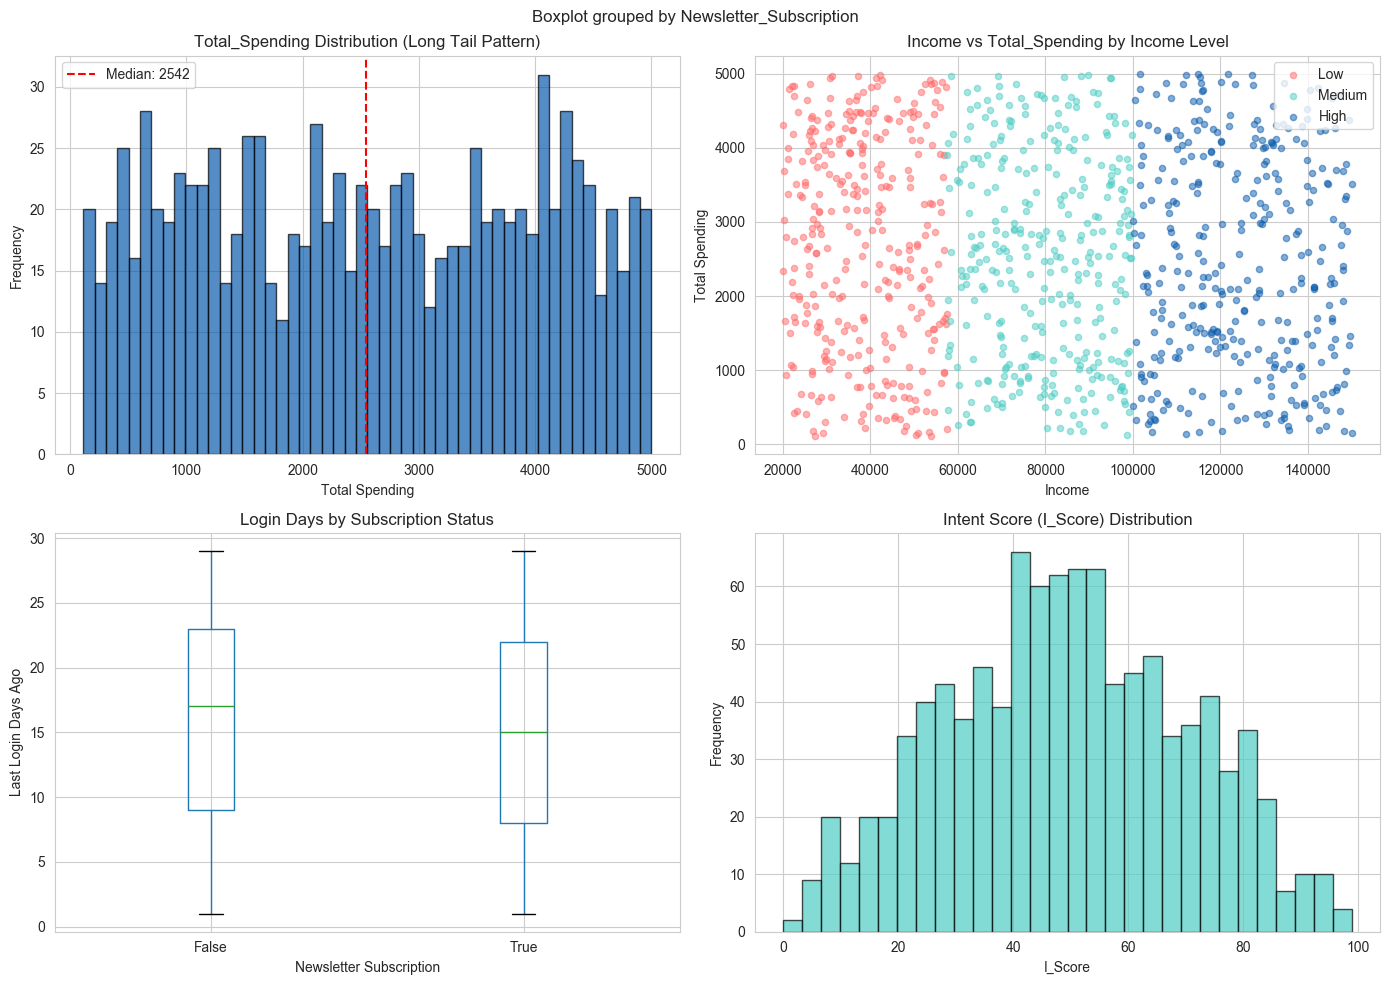

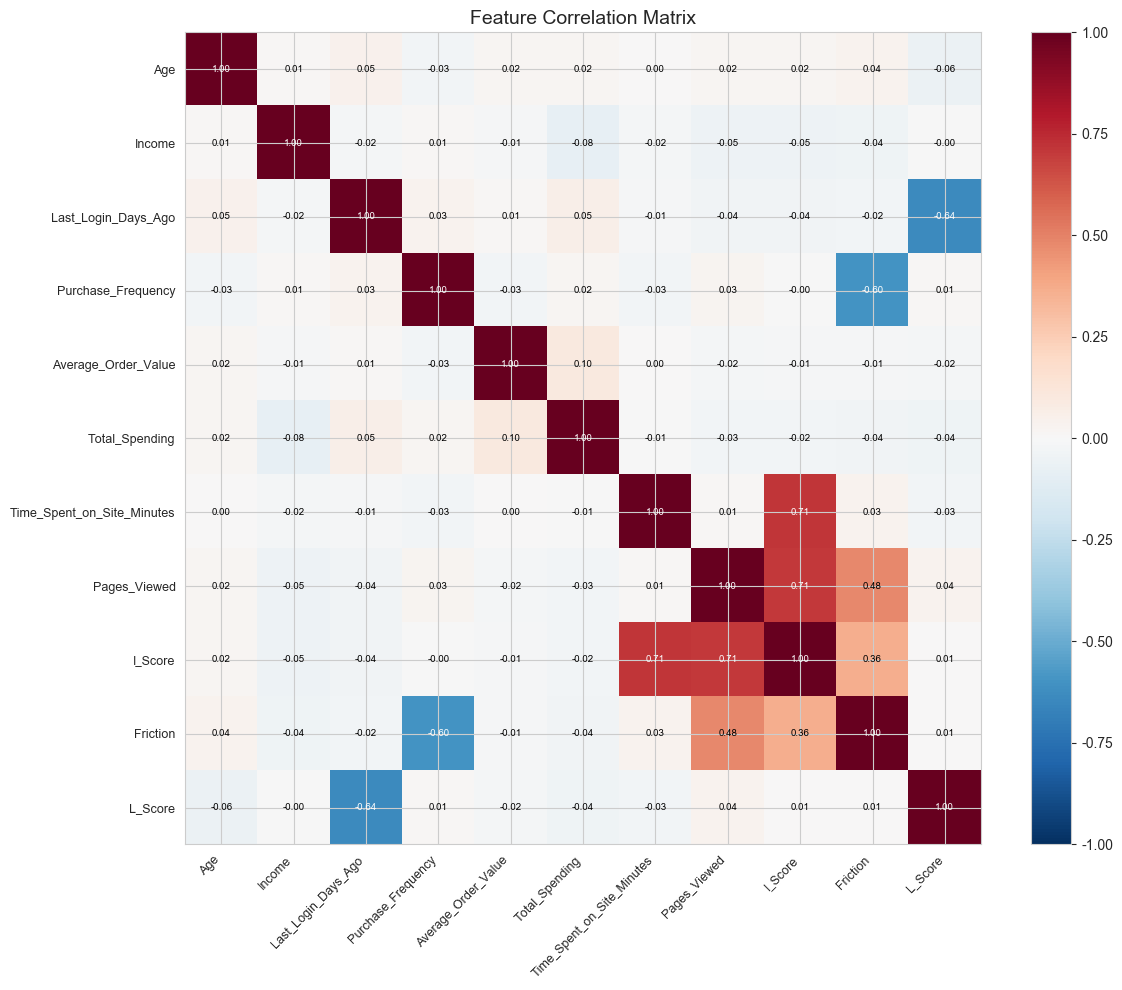


关键相关性分析:
Time_Spent vs Purchase_Frequency 相关系数: -0.028
Pages_Viewed vs Purchase_Frequency 相关系数: 0.026

高摩擦用户(前25%)特征:
  - 平均浏览页数: 34.3
  - 平均购买频率: 1.6
  - 平均消费金额: 2514

高收入低消费群体:
  - 用户数: 184
  - 占高收入群体比例: 54.1%


In [61]:
def perform_eda(df, output_dir):
    """EDA分析：分布、相关性、行为洞察"""

    print("\n" + "=" * 60)
    print("第三阶段：EDA探索性数据分析")
    print("=" * 60)

    ##### 1. 关键分布分析 #####
    # 第一步：先看与核心目标相关的“业务变量”的分布：Total_Spending, Income
    # 第二步：再看“行为变量”的分布：Pages_Viewed, Last_Login_Days_Ago, Newsletter_Subscription
    # 主要关注数据分布和极端值情况
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Total_Spending 分布
    axes[0, 0].hist(df['Total_Spending'], bins=50, edgecolor='black', alpha=0.7, color='#0B5CAD')
    axes[0, 0].set_title('Total_Spending Distribution (Long Tail Pattern)', fontsize=12)
    axes[0, 0].set_xlabel('Total Spending')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(df['Total_Spending'].median(), color='red', linestyle='--',
                       label=f'Median: {df["Total_Spending"].median():.0f}')
    axes[0, 0].legend()
    # 看消费是不是长尾（电商典型特征）：大多数人消费不高，少数人消费特别高
    # 消费有没有分层基础

    # Income vs Total_Spending 散点图
    colors = {'Low': '#FF6B6B', 'Medium': '#4ECDC4', 'High': '#0B5CAD'}
    for level in ['Low', 'Medium', 'High']:
        subset = df[df['Income_Level'] == level]
        axes[0, 1].scatter(subset['Income'], subset['Total_Spending'],
                          alpha=0.5, label=level, c=colors[level], s=20)
    axes[0, 1].set_title('Income vs Total_Spending by Income Level', fontsize=12)
    axes[0, 1].set_xlabel('Income')
    axes[0, 1].set_ylabel('Total Spending')
    axes[0, 1].legend()
    # 收入能否体现消费

    # Last_Login_Days_Ago vs Newsletter_Subscription 箱线图
    df.boxplot(column='Last_Login_Days_Ago', by='Newsletter_Subscription', ax=axes[1, 0])
    axes[1, 0].set_title('Login Days by Subscription Status', fontsize=12)
    axes[1, 0].set_xlabel('Newsletter Subscription')
    axes[1, 0].set_ylabel('Last Login Days Ago')
    # L-Score能否体现忠诚度

    # I_Score 分布
    axes[1, 1].hist(df['I_Score'], bins=30, edgecolor='black', alpha=0.7, color='#4ECDC4')
    axes[1, 1].set_title('Intent Score (I_Score) Distribution', fontsize=12)
    axes[1, 1].set_xlabel('I_Score')
    axes[1, 1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/eda_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    # I-Score是否有区分度


    ##### 2. 相关性分析 #####
    # 生成相关性矩阵与可视化热图
    numeric_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency',
                    'Average_Order_Value', 'Total_Spending', 'Time_Spent_on_Site_Minutes',
                    'Pages_Viewed', 'I_Score', 'Friction', 'L_Score']

    corr_matrix = df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(numeric_cols, fontsize=9)

    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha='center', va='center', fontsize=7,
                          color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

    ax.set_title('Feature Correlation Matrix', fontsize=14)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    ##### 3. 关键行为洞察 #####
    '''
    第三步：看“业务假设”是否成立？
    感兴趣 -> 停留更长、浏览更多，转化 -> 购买频率
    停留更长的人应该更可能购买吧？
    浏览更多的人应该更可能购买吧？
    '''
    # 用数据验证这些假设：先计算相关性，再对行为进行分析
    # 最关键行为：感兴趣但未下单、没有转化成功
    time_purchase_corr = df['Time_Spent_on_Site_Minutes'].corr(df['Purchase_Frequency'])
    pages_purchase_corr = df['Pages_Viewed'].corr(df['Purchase_Frequency'])

    print(f"\n关键相关性分析:")
    print(f"Time_Spent vs Purchase_Frequency 相关系数: {time_purchase_corr:.3f}")
    print(f"Pages_Viewed vs Purchase_Frequency 相关系数: {pages_purchase_corr:.3f}")
    # 结论：用户逛了很久但并不一定会买很多 -> 存在大量观光用户，没有贡献GMV

    # 定义高摩擦用户：它们到底是什么样子的？
    high_friction = df[df['Friction'] > df['Friction'].quantile(0.75)]
    print(f"\n高摩擦用户(前25%)特征:")
    print(f"  - 平均浏览页数: {high_friction['Pages_Viewed'].mean():.1f}")
    print(f"  - 平均购买频率: {high_friction['Purchase_Frequency'].mean():.1f}")
    print(f"  - 平均消费金额: {high_friction['Total_Spending'].mean():.0f}")

    # 定义高收入低消费-潜力群体：它们多不多？
    high_income_low_spend = df[(df['Income_Level'] == 'High') &
                               (df['Total_Spending'] < df['Total_Spending'].median())]
    print(f"\n高收入低消费群体:")
    print(f"  - 用户数: {len(high_income_low_spend)}")
    print(f"  - 占高收入群体比例: {len(high_income_low_spend)/len(df[df['Income_Level']=='High'])*100:.1f}%")

    return {
        'time_purchase_corr': time_purchase_corr,
        'pages_purchase_corr': pages_purchase_corr,
        'high_friction_count': len(high_friction),
        'high_income_low_spend_count': len(high_income_low_spend)
    }


eda_results = perform_eda(df, output_dir)

### 6. RFM-I模型构建

In [62]:
def build_rfm_model(df):
    """构建RFM-I模型：标准化、综合得分计算"""

    print("\n" + "=" * 60)
    print("第四阶段：RFM-I模型构建")
    print("=" * 60)

    # 归一化函数
    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100

    # R 最近消费时间（用登录代替） F 购买频率 M 消费金额
    df['R_Score'] = min_max_normalize(df['Last_Login_Days_Ago'], reverse=True) # 反向归一化，因为越近越好
    df['F_Score'] = min_max_normalize(df['Purchase_Frequency'])
    df['M_Score'] = min_max_normalize(df['Total_Spending'])
    df['RFM_Score'] = 0.2 * df['R_Score'] + 0.3 * df['F_Score'] + 0.5 * df['M_Score'] # M最重要，价值第一，F次之，R最轻
    df['I_Weight'] = df['I_Score'] / 500  # I_Score 0-100 -> 0-0.2 最多大概给用户增加 20% 的加成
    df['Final_Score'] = df['RFM_Score'] * (1 + df['I_Weight']) # 原得分加上修正系数的影响
    # 让 I 作为一个“放大器”，去提升高意向用户的综合得分

    print(f"R_Score 范围: [{df['R_Score'].min():.2f}, {df['R_Score'].max():.2f}]")
    print(f"F_Score 范围: [{df['F_Score'].min():.2f}, {df['F_Score'].max():.2f}]")
    print(f"M_Score 范围: [{df['M_Score'].min():.2f}, {df['M_Score'].max():.2f}]")
    print(f"RFM_Score 范围: [{df['RFM_Score'].min():.2f}, {df['RFM_Score'].max():.2f}]")
    print(f"Final_Score 范围: [{df['Final_Score'].min():.2f}, {df['Final_Score'].max():.2f}]")

    return df

df = build_rfm_model(df)
df[['User_ID', 'R_Score', 'F_Score', 'M_Score', 'I_Score', 'RFM_Score', 'Final_Score']].head()


第四阶段：RFM-I模型构建
R_Score 范围: [0.00, 100.00]
F_Score 范围: [0.00, 100.00]
M_Score 范围: [0.00, 100.00]
RFM_Score 范围: [4.72, 96.77]
Final_Score 范围: [5.26, 105.06]


,User_ID,R_Score,F_Score,M_Score,I_Score,RFM_Score,Final_Score
0,#1,85.714286,77.777778,49.805607,87.285385,65.378994,76.792255
1,#2,50.000000,77.777778,4.256190,76.638400,35.461428,40.896843
2,#3,3.571429,11.111111,74.769797,25.460637,41.432518,43.542314
3,#4,39.285714,33.333333,87.272355,73.136516,61.493320,70.488135
4,#5,96.428571,55.555556,89.830162,13.646357,80.867462,83.074554


### 7. 用户分层与画像

In [153]:
def classify_users(df):
    """用户分层：基于RFM-I模型进行精细化分层"""

    print("\n" + "=" * 60)
    print("第五阶段：用户分层与画像")
    print("=" * 60)

    def classify_user(row):
        r = row['R_Score']
        f = row['F_Score']
        m = row['M_Score']
        i = row['I_Score']
        income = row['Income_Level']
        friction = row['Friction']
        l = row['L_Score']

        # 第一次分层-基础RFM完整分层
        if r > 60 and f > 60 and m > 60:     # 高活跃、高频复购、高消费力  高价值
            base_label = "重要价值用户"
        elif r > 60 and f < 40 and m > 60:   # 高活跃、低频复购、高消费力  深耕用户，价值型
            base_label = "重要发展用户"
        elif r < 40 and f > 60 and m > 60:   # 低活跃、高频复购、高消费力  流失预警用户
            base_label = "重要保持用户"
        elif r < 40 and f < 40 and m > 60:   # 低活跃、低频复购、高消费力  流失高价值用户
            base_label = "重要挽留用户"
        elif r > 60 and f > 60 and m < 40:   # 高活跃、高频复购、低消费力  潜力用户，增长型
            base_label = "一般发展用户"
        elif r > 60 and f < 40 and m < 40:   # 高活跃、低频复购、低消费力  新用户
            base_label = "一般维持用户"
        elif r < 40 and f < 40 and m < 40:   # 低活跃、低频复购、低消费力  低价值
            base_label = "低价值用户"
        else:                                # 低活跃、高频复购、低消费力  不常登陆，常买东西但又没啥价值
            base_label = "一般用户"

        # 第二次分层-关键修正逻辑，找出业务上最值得重点区分的几类群体
        if f > 60 and m > 60 and i > 60: # 对"重要价值用户", "重要保持用户"细分
            return "核心VIP"  # 高复购、高消费且感兴趣的 -> 关注价值，不看活跃
        if r > 60 and m < 40 and i > 60 and friction > df['Friction'].quantile(0.6): # 对"一般维持用户", "一般发展用户"细分
            return "犹豫型潜力用户"  # 高活跃、低消费里面感兴趣、高摩擦的 -> 潜力型里未转化的
        if income == "High" and i > 60 and f < 40 and m < 40 : # 对"低价值用户", "一般维持用户"细分
            return "纠结土豪" # 高收入、感兴趣里面低复购、低消费的，也可称为高潜沉睡用户 -> 低价值里有钱的
        if income == "High" and r < 40 and m > 60: # 对"重要挽留用户", "重要保持用户"细分
            return "高值流失客"  # 高收入、高消费里低活跃的
        if income == "Low" and i > 60 and f < 40:
            return "隐形活跃者"  # 低收入里感兴趣但低复购的
        if income == "Low" and i < 40 and m < 40:
            return "羊毛党/低值"  # 低收入、不感兴趣且低消费的
        return base_label
        # 加上第一次分层中的重要发展，重要挽留，一般用户，共分为九类

    df['User_Segment'] = df.apply(classify_user, axis=1)

    # 分层统计
    segment_stats = df.groupby('User_Segment').agg({
        'User_ID': 'count',
        'Total_Spending': 'mean',
        'Purchase_Frequency': 'mean',
        'I_Score': 'mean',
        'Income': 'mean',
        'Final_Score': 'mean'
    }).round(2)

    segment_stats.columns = ['用户数', '平均消费', '平均购买频率', '平均意向分', '平均收入', '平均综合分']
    segment_stats['占比(%)'] = (segment_stats['用户数'] / len(df) * 100).round(1)
    segment_stats = segment_stats.sort_values('用户数', ascending=False)

    print("\n用户分层统计:")
    print(segment_stats.to_string())

    return df, segment_stats

df, segment_stats = classify_users(df)


第五阶段：用户分层与画像

用户分层统计:
              用户数     平均消费  平均购买频率  平均意向分       平均收入  平均综合分  占比(%)
User_Segment                                                      
一般用户          493  2396.14    5.11  47.96   83700.05  54.29   49.3
核心VIP          54  3912.19    7.65  71.73   72451.24  83.66    5.4
高值流失客          50  4112.86    4.36  38.54  121465.00  64.02    5.0
一般发展用户         48  1136.44    7.56  51.81   87023.81  57.37    4.8
低价值用户          48  1035.60    1.67  41.77   96614.25  20.64    4.8
重要发展用户         45  3844.13    1.56  47.89   84022.60  64.61    4.5
隐形活跃者          41  2935.90    1.54  74.84   37357.90  49.39    4.1
一般维持用户         39  1049.33    1.56  41.48   95466.38  33.77    3.9
重要挽留用户         39  4198.74    1.46  47.14   64838.74  55.57    3.9
重要价值用户         37  4075.86    7.51  34.53   75977.81  87.23    3.7
犹豫型潜力用户        35  1093.69    2.69  75.09   79283.09  39.63    3.5
羊毛党/低值         32  1019.56    5.50  23.08   37896.19  37.05    3.2
重要保持用户         30  4122.10    7.53  39.

### 8. 生成用户画像可视化

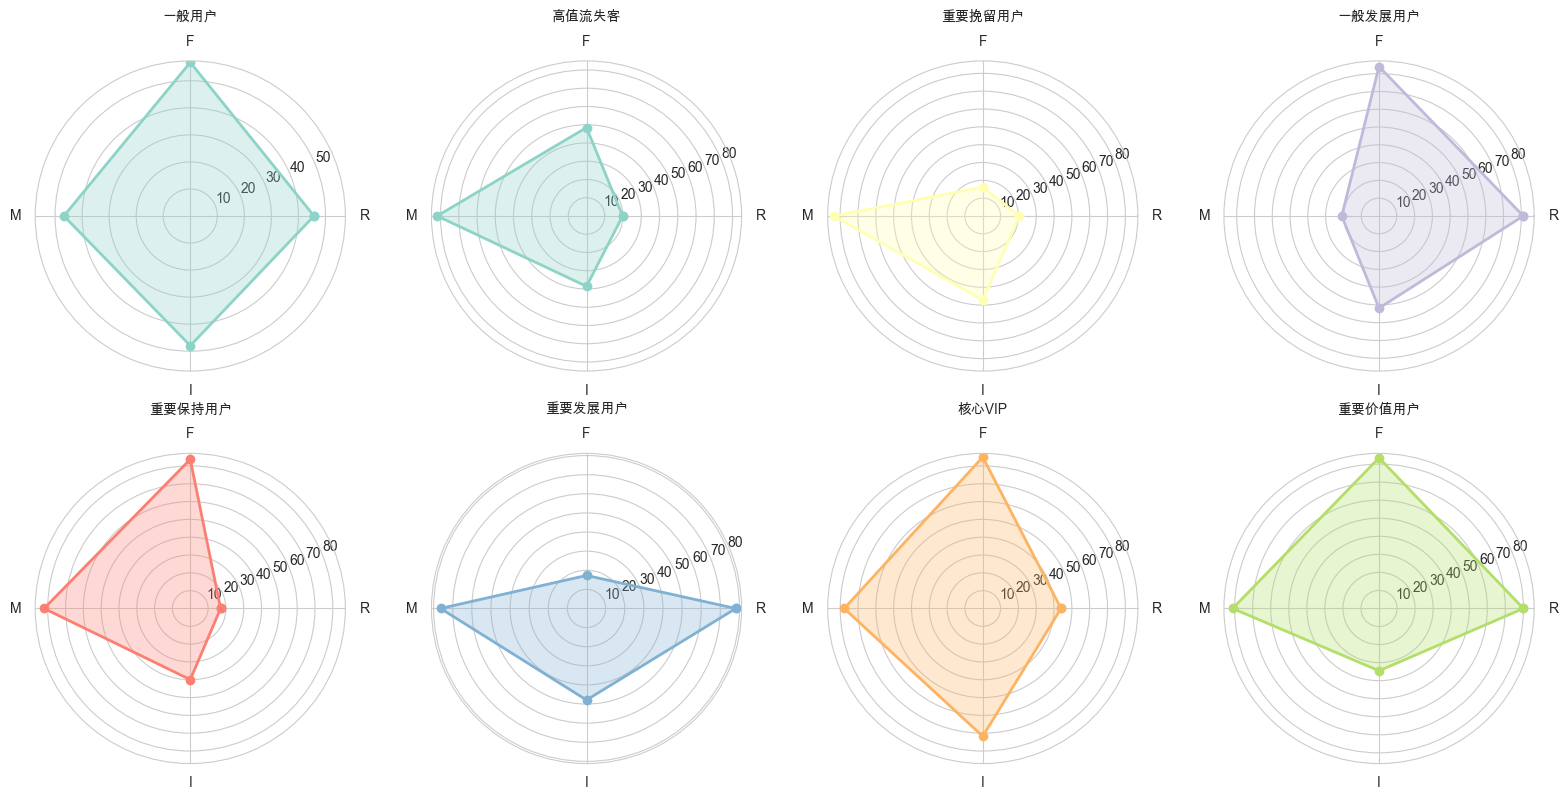

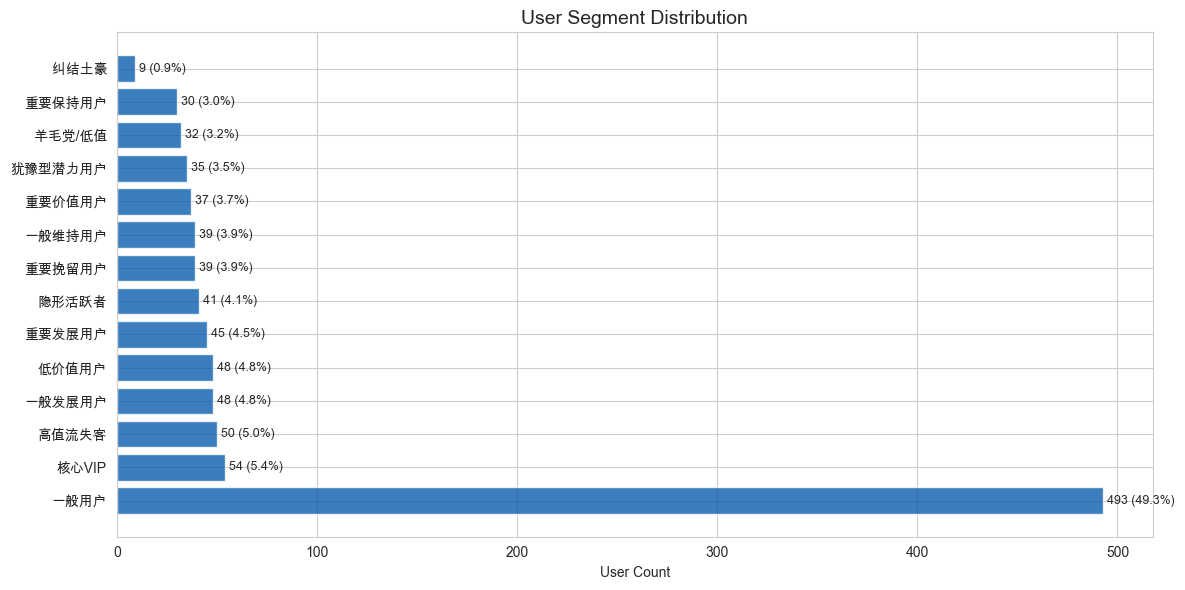

In [154]:
def generate_segment_portrait(df, output_dir):
    """生成用户画像可视化：雷达图和分布柱状图"""

    # 分层雷达图
    segments = df['User_Segment'].unique()
    metrics = ['R_Score', 'F_Score', 'M_Score', 'I_Score']

    segment_means = df.groupby('User_Segment')[metrics].mean()

    fig, axes = plt.subplots(2, 4, figsize=(16, 8), subplot_kw=dict(polar=True))
    axes = axes.flatten()

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    colors = plt.cm.Set3(np.linspace(0, 1, len(segments)))

    for idx, segment in enumerate(segments[:8]):
        if idx >= len(axes):
            break
        ax = axes[idx]
        values = segment_means.loc[segment].tolist()
        values += values[:1]

        ax.fill(angles, values, alpha=0.3, color=colors[idx])
        ax.plot(angles, values, 'o-', color=colors[idx], linewidth=2)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(['R', 'F', 'M', 'I'], fontsize=10)
        ax.set_title(segment, fontsize=10, pad=10)

    for idx in range(len(segments), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{output_dir}/segment_radar.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # 分层分布柱状图
    segment_counts = df['User_Segment'].value_counts()

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(segment_counts.index, segment_counts.values, color='#0B5CAD', alpha=0.8)
    ax.set_xlabel('User Count')
    ax.set_title('User Segment Distribution', fontsize=14)

    for bar, count in zip(bars, segment_counts.values):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                f'{count} ({count/len(df)*100:.1f}%)', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{output_dir}/segment_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

generate_segment_portrait(df, output_dir)


第六阶段：ROI测算

【假设参数】
  总预算: 10000元
  优惠券成本: 10元/人
  平均客单价: 104元

【转化率假设】
  RFM前20%用户：自然转化率 20.0%，发券后 30.0%，边际提升 10.0%
  核心用户：自然转化率 25.0%，发券后 30.0%，边际提升 5.0%
  潜力用户：自然转化率 1.0%，发券后 20.0%，边际提升 19.0%

【方案A - 传统RFM策略】
  目标用户数: 200
  成本: 2000元
  边际收益（增量）: 2081元
  边际ROI: 4.0%

【方案B - 优化RFI策略】
  核心用户: 91
  新挖掘潜力用户: 178
  总目标用户数: 269
  实际成本: 2690元 (预算使用率: 26.9%)
  边际收益（增量）: 3992元
  边际ROI: 48.4%


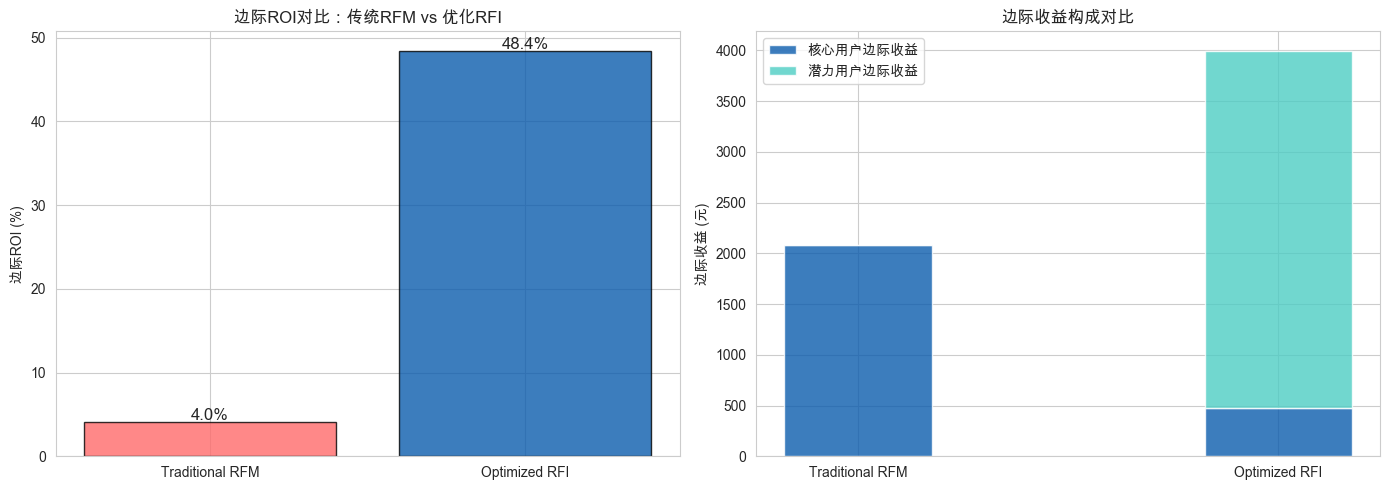

In [155]:
# 9. ROI测算
def calculate_roi(df, output_dir):
    """ROI测算：传统RFM vs 优化RFI策略对比（边际收益法，参数可调）"""

    print("\n" + "=" * 60)
    print("第六阶段：ROI测算")
    print("=" * 60)

    # ================= 可调整参数=================
    total_budget = 10000          # 总预算（元）
    coupon_cost = 10               # 每张优惠券成本（元）
    aov = df['Average_Order_Value'].mean()  # 平均客单价（元）

    # 转化率假设（可根据历史数据校准）
    # 核心用户
    core_natural = 0.25            # 核心用户无券自然转化率
    core_with_coupon = 0.30        # 核心用户发券后转化率（本来就爱买，不会提升太多）
    # 潜力用户
    potential_natural = 0.01       # 潜力用户自然转化率
    potential_with_coupon = 0.20   # 潜力用户发券后转化率（可调高至20%-25%） 自身转化低，所以带来的提升大
    # 一般用户（用于方案A的基线）
    general_natural = 0.02          # 一般用户自然转化率
    # RFM前20%用户的自然转化率（介于核心和一般之间）
    rfm20_natural = 0.20            # 可根据实际数据调整，例如：RFM高分用户通常转化率较高
    rfm20_with_coupon = 0.30        # 发券后转化率（通常不会超过核心用户）

    # 转化率的边际提升
    core_lift = core_with_coupon - core_natural
    potential_lift = potential_with_coupon - potential_natural
    rfm20_lift = rfm20_with_coupon - rfm20_natural

    # ================= 方案A：传统RFM策略 =================
    top20_threshold = df['RFM_Score'].quantile(0.80)
    rfm_top20 = df[df['RFM_Score'] >= top20_threshold] # 传统的投放人群是得分前20%的用户
    target_a_count = min(len(rfm_top20), total_budget // coupon_cost) # 目标人数
    cost_a = target_a_count * coupon_cost # 营销成本 = 目标人数 x 单券成本

    incremental_revenue_a = target_a_count * rfm20_lift * aov # 增量收益 = 目标人数 x 边际提升 x 平均客单价
    roi_a = (incremental_revenue_a - cost_a) / cost_a * 100 if cost_a > 0 else 0

    # ================= 方案B：优化RFI策略 =================
    core_users = df[df['User_Segment'].isin(['核心VIP', '重要价值用户'])] # 新挖掘的核心用户与传统核心用户
    potential_users = df[df['User_Segment'].isin(['纠结土豪', '犹豫型潜力用户', '高值流失客', '重要挽留用户', '重要发展用户'])]
    # 新挖掘的潜力用户与传统潜力用户

    # 分配预算：优先核心用户（用80%预算），剩余给潜力用户
    core_count = min(len(core_users), int(total_budget * 0.8 / coupon_cost)) # 核心用户目标人数，最多用掉80%预算
    remaining_budget = total_budget - core_count * coupon_cost # 剩余预算
    potential_count = min(len(potential_users), remaining_budget // coupon_cost) # 潜力用户目标人数
    target_b_count = core_count + potential_count # 总目标人数
    cost_b = target_b_count * coupon_cost # 营销成本

    incremental_revenue_b = core_count * core_lift * aov + potential_count * potential_lift * aov
    roi_b = (incremental_revenue_b - cost_b) / cost_b * 100 if cost_b > 0 else 0

    # ================= 输出结果 =================
    print(f"\n【假设参数】")
    print(f"  总预算: {total_budget}元")
    print(f"  优惠券成本: {coupon_cost}元/人")
    print(f"  平均客单价: {aov:.0f}元")

    print(f"\n【转化率假设】")
    print(f"  RFM前20%用户：自然转化率 {rfm20_natural*100:.1f}%，发券后 {rfm20_with_coupon*100:.1f}%，边际提升 {rfm20_lift*100:.1f}%")
    print(f"  核心用户：自然转化率 {core_natural*100:.1f}%，发券后 {core_with_coupon*100:.1f}%，边际提升 {core_lift*100:.1f}%")
    print(f"  潜力用户：自然转化率 {potential_natural*100:.1f}%，发券后 {potential_with_coupon*100:.1f}%，边际提升 {potential_lift*100:.1f}%")

    print(f"\n【方案A - 传统RFM策略】")
    print(f"  目标用户数: {target_a_count}")
    print(f"  成本: {cost_a}元")
    print(f"  边际收益（增量）: {incremental_revenue_a:.0f}元")
    print(f"  边际ROI: {roi_a:.1f}%")

    print(f"\n【方案B - 优化RFI策略】")
    print(f"  核心用户: {core_count}")
    print(f"  新挖掘潜力用户: {potential_count}")
    print(f"  总目标用户数: {target_b_count}")
    print(f"  实际成本: {cost_b}元 (预算使用率: {cost_b/total_budget*100:.1f}%)")
    print(f"  边际收益（增量）: {incremental_revenue_b:.0f}元")
    print(f"  边际ROI: {roi_b:.1f}%")

    # ROI对比可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 边际ROI对比
    strategies = ['Traditional RFM', 'Optimized RFI']
    rois = [roi_a, roi_b]
    colors = ['#FF6B6B', '#0B5CAD']

    bars = axes[0].bar(strategies, rois, color=colors, alpha=0.8, edgecolor='black')
    axes[0].set_ylabel('边际ROI (%)')
    axes[0].set_title('边际ROI对比：传统RFM vs 优化RFI', fontsize=12)
    for bar, roi in zip(bars, rois):  # 添加标注
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{roi:.1f}%', ha='center', fontsize=12, fontweight='bold')

    # 边际收益构成对比
    x = np.arange(2)
    width = 0.35

    core_marginal = [incremental_revenue_a, core_count * core_lift * aov]
    potential_marginal = [0, potential_count * potential_lift * aov] # 因为传统没有潜力用户

    axes[1].bar(x, core_marginal, width, label='核心用户边际收益', color='#0B5CAD', alpha=0.8)
    axes[1].bar(x, potential_marginal, width, bottom=core_marginal, label='潜力用户边际收益', color='#4ECDC4', alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(strategies)
    axes[1].set_ylabel('边际收益 (元)')
    axes[1].set_title('边际收益构成对比', fontsize=12)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{output_dir}/roi_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    return {
        'strategy_a': {
            'target_count': int(target_a_count),
            'cost': cost_a,
            'incremental_revenue': incremental_revenue_a,
            'marginal_roi': roi_a
        },
        'strategy_b': {
            'core_count': int(core_count),
            'potential_count': int(potential_count),
            'total_count': int(target_b_count),
            'actual_cost': cost_b,
            'budget_used_ratio': cost_b/total_budget,
            'incremental_revenue': incremental_revenue_b,
            'marginal_roi': roi_b
        },
        'params': {
            'budget': total_budget,
            'coupon_cost': coupon_cost,
            'aov': aov,
            'rfm20_lift': rfm20_lift,
            'core_lift': core_lift,
            'potential_lift': potential_lift
        }
    }
roi_results = calculate_roi(df, output_dir)